In [38]:
from google.colab import files
uploaded = files.upload()

Saving event_analysis.csv to event_analysis.csv


In [39]:
import pandas as pd
import numpy as np

df = pd.read_csv('event_analysis.csv')

df['event_time'] = pd.to_datetime(df['event_time'])

print(df.shape)
display(df.head())

(2528, 16)


,NEWSID,company,event_time,subject_group,SUBCATNAME,NEWSSUB,CRITICALNEWS,return_5min,return_30min,return_60min,return_close,D+1,D+5,D+10,D+20,volume_impact
0,989d8d2f-2b08-4a1c-8d43-f55bae61c178,RELIANCE,2026-08-18 20:06:38.747,Press / Public Updates,General,Update On Institutional Investors'' Meeting - ...,0,0.007586,-0.106205,-0.311030,-0.546199,NaN,NaN,NaN,NaN,-46.088544
1,b0bc3391-c0aa-44d6-be8d-a10b20b10247,RELIANCE,2026-08-18 17:44:19.310,Press / Public Updates,General,"News Clarification - ""SC Slaps Rs 10 Lakh Fine...",0,0.007586,-0.106205,-0.311030,-0.546199,NaN,NaN,NaN,NaN,-46.088544
2,32de7735-b8e6-4653-b377-0c5762be73af,RVNL,2026-08-18 14:24:13.290,Investor Communication,Earnings Call Transcript,Announcement under Regulation 30 (LODR)-Earnin...,0,-0.004431,0.075321,-0.132920,-0.974745,NaN,NaN,NaN,NaN,40.386558
3,4acb87f7-f8ca-4f17-a825-1eb510af3ee8,RELIANCE,2026-08-17 17:18:06.063,Regulatory / Compliance,Clarification,Clarification sought from Reliance Industries Ltd,1,0.152486,0.998780,0.930162,-0.045746,NaN,NaN,NaN,NaN,83.003637
4,dfebd7ae-ef5c-498b-bd7e-d6c9f5287d66,HDFCBANK,2026-08-16 19:43:27.497,Investor Communication,Analyst / Investor Meet,Announcement under Regulation 30 (LODR)-Analys...,0,-0.089476,-0.006883,-0.055062,-0.887879,NaN,NaN,NaN,NaN,-28.541510


In [40]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nMissing values:")
print(df.isna().sum())

Rows: 2528
Columns: 16

Missing values:
NEWSID            0
company           0
event_time        0
subject_group     0
SUBCATNAME        4
NEWSSUB           0
CRITICALNEWS      0
return_5min       0
return_30min      0
return_60min      0
return_close      0
D+1              70
D+5              70
D+10             70
D+20             70
volume_impact     0
dtype: int64


In [41]:
print("\nDuplicate NEWSID:", df["NEWSID"].duplicated().sum())
print("\nCompanies:")
print(df["company"].value_counts())

print("\nSubject groups:")
print(df["subject_group"].value_counts())


Duplicate NEWSID: 0

Companies:
company
RELIANCE    844
HDFCBANK    605
RVNL        464
NYKAA       339
HAL         276
Name: count, dtype: int64

Subject groups:
subject_group
Press / Public Updates     949
Regulatory / Compliance    527
Investor Communication     331
Board / Management         268
Corporate Actions          257
Orders / Business          143
Financial Results           53
Name: count, dtype: int64


In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
!ls -lah '/content/drive/.shortcut-targets-by-id/1SfOSZZ82p03AUNw9cDWwYWoNAPijKPQn/Quant Analyst Intern'

total 89M
-r-------- 1 root root 1.6M Aug 20 05:26 corporate_announcements.csv
-r-------- 1 root root 2.6M Aug 20 05:26 corporate_announcements.jsonl
-r-------- 1 root root  18M Aug 20 06:46 HAL.csv
-r-------- 1 root root  17M Aug 20 06:45 HDFCBANK.csv
-r-------- 1 root root 2.6K Aug 20 05:26 metadata.json
-r-------- 1 root root  17M Aug 20 06:46 NYKAA.csv
-r-------- 1 root root  61K Aug 22 07:16 Quant_Analyst_Intern_Assessment.pdf
-r-------- 1 root root  18M Aug 20 06:44 RELIANCE.csv
-r-------- 1 root root  17M Aug 20 06:45 RVNL.csv


In [44]:
reliance = pd.read_csv('/content/drive/.shortcut-targets-by-id/1SfOSZZ82p03AUNw9cDWwYWoNAPijKPQn/Quant Analyst Intern/RELIANCE.csv')
hdfcbank = pd.read_csv('/content/drive/.shortcut-targets-by-id/1SfOSZZ82p03AUNw9cDWwYWoNAPijKPQn/Quant Analyst Intern/HDFCBANK.csv')
nykaa = pd.read_csv('/content/drive/.shortcut-targets-by-id/1SfOSZZ82p03AUNw9cDWwYWoNAPijKPQn/Quant Analyst Intern/NYKAA.csv')
hal = pd.read_csv('/content/drive/.shortcut-targets-by-id/1SfOSZZ82p03AUNw9cDWwYWoNAPijKPQn/Quant Analyst Intern/HAL.csv')
rvnl = pd.read_csv('/content/drive/.shortcut-targets-by-id/1SfOSZZ82p03AUNw9cDWwYWoNAPijKPQn/Quant Analyst Intern/RVNL.csv')


In [45]:
reliance['company'] = 'RELIANCE'
hdfcbank['company'] = 'HDFCBANK'
nykaa['company'] = 'NYKAA'
hal['company'] = 'HAL'
rvnl['company'] = 'RVNL'


market = pd.concat([
    reliance,
    hdfcbank,
    nykaa,
    hal,
    rvnl
], ignore_index= True)

print(market.shape)

(1387547, 8)


In [46]:
market['date'] = pd.to_datetime(market['date'])

In [47]:
market = market.sort_values(
    ["company", "date"]
).reset_index(drop=True)



df = df.sort_values(
    ["company", "event_time"]
).reset_index(drop=True)

In [48]:
print(market[["company", "date"]].head(10))
print(df[["company", "event_time"]].head(10))

  company                date
0     HAL 2023-08-21 09:15:00
1     HAL 2023-08-21 09:16:00
2     HAL 2023-08-21 09:17:00
3     HAL 2023-08-21 09:18:00
4     HAL 2023-08-21 09:19:00
5     HAL 2023-08-21 09:20:00
6     HAL 2023-08-21 09:21:00
7     HAL 2023-08-21 09:22:00
8     HAL 2023-08-21 09:23:00
9     HAL 2023-08-21 09:24:00
  company              event_time
0     HAL 2023-08-23 17:38:08.580
1     HAL 2023-08-28 17:56:31.123
2     HAL 2023-08-31 17:56:43.077
3     HAL 2023-09-01 16:15:05.740
4     HAL 2023-09-01 17:01:27.883
5     HAL 2023-09-01 17:02:53.890
6     HAL 2023-09-01 17:06:56.487
7     HAL 2023-09-01 17:09:24.247
8     HAL 2023-09-12 14:31:50.297
9     HAL 2023-09-15 17:22:38.493


In [49]:
trading_dates = {}

for company in market["company"].unique():

    dates = (
        market[market["company"] == company]["date"]
        .dt.date
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    trading_dates[company] = dates

In [50]:
def get_d_returns(row):

    company = row["company"]
    event_date = pd.to_datetime(row["event_time"]).date()

    dates = trading_dates[company]

    future_dates = [d for d in dates if d > event_date]

    result = {
        "D+1": None,
        "D+5": None,
        "D+10": None,
        "D+20": None
    }

    required_days = {
        "D+1": 1,
        "D+5": 5,
        "D+10": 10,
        "D+20": 20
    }

    for name, n in required_days.items():

        if len(future_dates) >= n:

            target_date = future_dates[n - 1]

            target = market[
                (market["company"] == company) &
                (market["date"].dt.date == target_date)
            ]

            if len(target) > 0:
                result[name] = target["close"].iloc[-1]

    return result

In [51]:
row = df[df["D+20"].isna()].iloc[0]

test = get_d_returns(row)

print(test)

{'D+1': np.float64(4590.0), 'D+5': np.float64(4645.0), 'D+10': np.float64(4995.0), 'D+20': None}


In [52]:
row = df[df["D+20"].isna()].iloc[0]

company = row["company"]
event_date = pd.to_datetime(row["event_time"]).date()

future_dates = [
    d for d in trading_dates[company]
    if d > event_date
]

print("Company:", company)
print("Event date:", event_date)
print("Number of future trading days:", len(future_dates))
print("Future dates:", future_dates)

Company: HAL
Event date: 2026-07-29
Number of future trading days: 15
Future dates: [datetime.date(2026, 7, 30), datetime.date(2026, 7, 31), datetime.date(2026, 8, 3), datetime.date(2026, 8, 4), datetime.date(2026, 8, 5), datetime.date(2026, 8, 6), datetime.date(2026, 8, 7), datetime.date(2026, 8, 10), datetime.date(2026, 8, 11), datetime.date(2026, 8, 12), datetime.date(2026, 8, 13), datetime.date(2026, 8, 14), datetime.date(2026, 8, 17), datetime.date(2026, 8, 18), datetime.date(2026, 8, 19)]


In [53]:
missing_rows = df[df["D+20"].isna()].copy()

print("Missing events:", len(missing_rows))

Missing events: 70


In [54]:
for idx, row in missing_rows.iterrows():

    company = row["company"]
    event_date = pd.to_datetime(row["event_time"]).date()

    future_dates = [
        d for d in trading_dates[company]
        if d > event_date
    ]

    print(
        "Row:", idx,
        "| Company:", company,
        "| Event:", event_date,
        "| Future trading days:", len(future_dates)
    )

Row: 268 | Company: HAL | Event: 2026-07-29 | Future trading days: 15
Row: 269 | Company: HAL | Event: 2026-07-29 | Future trading days: 15
Row: 270 | Company: HAL | Event: 2026-07-31 | Future trading days: 13
Row: 271 | Company: HAL | Event: 2026-08-04 | Future trading days: 11
Row: 272 | Company: HAL | Event: 2026-08-04 | Future trading days: 11
Row: 273 | Company: HAL | Event: 2026-08-04 | Future trading days: 11
Row: 274 | Company: HAL | Event: 2026-08-05 | Future trading days: 10
Row: 275 | Company: HAL | Event: 2026-08-12 | Future trading days: 5
Row: 871 | Company: HDFCBANK | Event: 2026-07-24 | Future trading days: 18
Row: 872 | Company: HDFCBANK | Event: 2026-07-24 | Future trading days: 18
Row: 873 | Company: HDFCBANK | Event: 2026-07-27 | Future trading days: 17
Row: 874 | Company: HDFCBANK | Event: 2026-07-31 | Future trading days: 13
Row: 875 | Company: HDFCBANK | Event: 2026-07-31 | Future trading days: 13
Row: 876 | Company: HDFCBANK | Event: 2026-08-05 | Future trading 

In [55]:
for idx, row in missing_rows.iterrows():

    company = row["company"]
    event_date = pd.to_datetime(row["event_time"]).date()

    before_event = market[
        (market["company"] == company) &
        (market["date"].dt.date <= event_date)
    ]

    if len(before_event) == 0:
        continue

    baseline = before_event["close"].iloc[-1]

    future_dates = [
        d for d in trading_dates[company]
        if d > event_date
    ]

    for column, n in {
        "D+1": 1,
        "D+5": 5,
        "D+10": 10,
        "D+20": 20
    }.items():

        if len(future_dates) >= n:

            target_date = future_dates[n - 1]

            target_data = market[
                (market["company"] == company) &
                (market["date"].dt.date == target_date)
            ]

            if len(target_data) > 0:

                target_close = target_data["close"].iloc[-1]

                return_value = (
                    (target_close - baseline) / baseline
                ) * 100

                df.loc[idx, column] = return_value

In [56]:
print(df[["D+1", "D+5", "D+10", "D+20"]].isna().sum())

D+1      0
D+5     11
D+10    22
D+20    69
dtype: int64


In [57]:
print(df[["D+1", "D+5", "D+10", "D+20"]].notna().sum())

D+1     2528
D+5     2517
D+10    2506
D+20    2459
dtype: int64


In [58]:
final_data = df[
    [
        "NEWSID",
        "company",
        "event_time",
        "subject_group",
        "SUBCATNAME",
        "NEWSSUB",
        "CRITICALNEWS",
        "return_5min",
        "return_30min",
        "return_60min",
        "return_close",
        "D+1",
        "D+5",
        "D+10",
        "D+20",
        "volume_impact"
    ]
].copy()

final_data.to_csv("event_analysis_final.csv", index=False)

print("Shape:", final_data.shape)
display(final_data.head())

Shape: (2528, 16)


,NEWSID,company,event_time,subject_group,SUBCATNAME,NEWSSUB,CRITICALNEWS,return_5min,return_30min,return_60min,return_close,D+1,D+5,D+10,D+20,volume_impact
0,d9de7773-d48b-4140-904a-6f736773dc4c,HAL,2023-08-23 17:38:08.580,Corporate Actions,Dividend Updates,Announcement under Regulation 30 (LODR)-Divide...,0,0.284230,-0.127414,-0.735078,145.859061,-1.688934,-1.386438,1.754474,-2.500630,223.354583
1,5d789c9b-6590-4157-a9c4-2a661aeae2bd,HAL,2023-08-28 17:56:31.123,Press / Public Updates,General,Disclosure Under Regulation 30 Of The SEBI LOD...,0,-0.316052,-0.621910,-0.744252,155.747566,-0.015370,1.357721,1.188646,-1.716364,-23.077396
2,a68a35aa-c8cb-40f8-b6f7-a065af684a3b,HAL,2023-08-31 17:56:43.077,Corporate Actions,AGM,Shareholder Meeting / Postal Ballot-Outcome of...,1,0.525725,0.653328,1.163740,156.073908,0.631019,4.054739,0.101368,-0.717182,-72.051418
3,31cec2fa-69f9-4098-961d-c9845b8917bd,HAL,2023-09-01 16:15:05.740,Corporate Actions,AGM,Shareholder Meeting / Postal Ballot-Scrutinize...,1,0.146309,-0.181626,-0.131174,153.115383,-0.360120,2.974137,0.397895,-3.548314,-19.512488
4,1dc927a7-73bf-490f-be65-3a36e7119b6a,HAL,2023-09-01 17:01:27.883,Press / Public Updates,General,Disclosures Of Material Events Arising Out Of ...,0,0.146309,-0.181626,-0.131174,153.115383,-0.360120,2.974137,0.397895,-3.548314,-19.512488


In [59]:
from google.colab import files

final_data.to_csv("event_analysis_final.csv", index=False)

files.download("event_analysis_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
return_cols = [
    "return_5min",
    "return_30min",
    "return_60min",
    "return_close",
    "D+1",
    "D+5",
    "D+10",
    "D+20"
]

summary = final_data[return_cols].describe().T

display(summary)




,count,mean,std,min,25%,50%,75%,max
return_5min,2528.0,0.006794,0.581560,-4.311975,-0.194053,0.007586,0.188530,5.919616
return_30min,2528.0,-0.034071,1.066362,-6.587324,-0.387156,-0.022361,0.308510,7.198533
return_60min,2528.0,-0.035498,1.283311,-7.914706,-0.492958,-0.029882,0.383549,8.868502
return_close,2528.0,3.396448,37.673223,-65.061748,-13.586174,-5.464003,9.586034,173.980832
D+1,2528.0,0.030549,1.944874,-11.196911,-0.913088,-0.038641,0.811245,15.076704
D+5,2517.0,0.384450,4.849764,-18.497519,-2.110927,0.271191,2.344468,47.687515
D+10,2506.0,0.784655,6.824061,-20.847280,-2.918408,0.123865,3.463652,55.651470
D+20,2459.0,1.263086,9.214508,-30.449791,-3.903611,-0.126665,5.269050,65.232975


In [61]:
for col in return_cols:

    valid = final_data[col].dropna()

    positive = (valid > 0).sum()
    negative = (valid < 0).sum()

    print(
        col,
        "| Valid:", len(valid),
        "| Positive:", round(positive / len(valid) * 100, 2), "%",
        "| Negative:", round(negative / len(valid) * 100, 2), "%"
    )

return_5min | Valid: 2528 | Positive: 50.24 % | Negative: 47.86 %
return_30min | Valid: 2528 | Positive: 47.43 % | Negative: 51.58 %
return_60min | Valid: 2528 | Positive: 47.63 % | Negative: 51.74 %
return_close | Valid: 2528 | Positive: 37.26 % | Negative: 62.74 %
D+1 | Valid: 2528 | Positive: 48.06 % | Negative: 51.34 %
D+5 | Valid: 2517 | Positive: 53.52 % | Negative: 46.36 %
D+10 | Valid: 2506 | Positive: 50.6 % | Negative: 49.32 %
D+20 | Valid: 2459 | Positive: 48.92 % | Negative: 50.67 %


In [62]:
print(final_data["volume_impact"].describe())

print(
    "\nAverage volume impact:",
    round(final_data["volume_impact"].mean(), 2),
    "%"
)

print(
    "Median volume impact:",
    round(final_data["volume_impact"].median(), 2),
    "%"
)





count     2528.000000
mean        81.541840
std        357.188738
min        -98.944344
25%        -41.216491
50%          0.415424
75%         75.405245
max      11536.729087
Name: volume_impact, dtype: float64

Average volume impact: 81.54 %
Median volume impact: 0.42 %


In [63]:
overall = pd.DataFrame({
    "Metric": return_cols,
    "Mean": [final_data[c].mean() for c in return_cols],
    "Median": [final_data[c].median() for c in return_cols],
    "Std": [final_data[c].std() for c in return_cols],
    "Valid Events": [final_data[c].notna().sum() for c in return_cols]
})

display(overall.round(4))

,Metric,Mean,Median,Std,Valid Events
0,return_5min,0.0068,0.0076,0.5816,2528
1,return_30min,-0.0341,-0.0224,1.0664,2528
2,return_60min,-0.0355,-0.0299,1.2833,2528
3,return_close,3.3964,-5.4640,37.6732,2528
4,D+1,0.0305,-0.0386,1.9449,2528
5,D+5,0.3844,0.2712,4.8498,2517
6,D+10,0.7847,0.1239,6.8241,2506
7,D+20,1.2631,-0.1267,9.2145,2459


In [64]:
big = final_data[
    final_data["return_close"].abs() > 50
][
    [
        "NEWSID",
        "company",
        "event_time",
        "return_5min",
        "return_30min",
        "return_60min",
        "return_close"
    ]
]

print("Events with |return_close| > 50%:", len(big))

display(big.head(10))

Events with |return_close| > 50%: 362


,NEWSID,company,event_time,return_5min,return_30min,return_60min,return_close
0,d9de7773-d48b-4140-904a-6f736773dc4c,HAL,2023-08-23 17:38:08.580,0.284230,-0.127414,-0.735078,145.859061
1,5d789c9b-6590-4157-a9c4-2a661aeae2bd,HAL,2023-08-28 17:56:31.123,-0.316052,-0.621910,-0.744252,155.747566
2,a68a35aa-c8cb-40f8-b6f7-a065af684a3b,HAL,2023-08-31 17:56:43.077,0.525725,0.653328,1.163740,156.073908
3,31cec2fa-69f9-4098-961d-c9845b8917bd,HAL,2023-09-01 16:15:05.740,0.146309,-0.181626,-0.131174,153.115383
4,1dc927a7-73bf-490f-be65-3a36e7119b6a,HAL,2023-09-01 17:01:27.883,0.146309,-0.181626,-0.131174,153.115383
5,6e4f0ba2-3234-4376-99c8-779b8c494450,HAL,2023-09-01 17:02:53.890,0.146309,-0.181626,-0.131174,153.115383
6,e71b6c61-387e-45fd-a140-64bfee494ec3,HAL,2023-09-01 17:06:56.487,0.146309,-0.181626,-0.131174,153.115383
7,02f95dcd-6657-49c6-9f86-a69bdf9ca5e6,HAL,2023-09-01 17:09:24.247,0.146309,-0.181626,-0.131174,153.115383
8,7f854943-2b8a-4d5f-a4a7-4538081cd1d5,HAL,2023-09-12 14:31:50.297,0.086015,-0.182149,0.166970,153.845375
9,a9b41833-c759-4490-b839-c4f0f0b89aac,HAL,2023-09-15 17:22:38.493,-0.341111,-0.467174,-0.875025,148.022543


In [65]:
row = final_data.iloc[0]

company = row["company"]
event_time = pd.to_datetime(row["event_time"])

day = event_time.date()

day_data = market[
    (market["company"] == company) &
    (market["date"].dt.date == day)
]

print("Company:", company)
print("Event time:", event_time)
print("First price:", day_data["close"].iloc[0])
print("Last price:", day_data["close"].iloc[-1])
print("Our return_close:", row["return_close"])

Company: HAL
Event time: 2023-08-23 17:38:08.580000
First price: 1952.5
Last price: 2020.3
Our return_close: 145.8590610604724


In [66]:
row = final_data.iloc[0]

company = row["company"]
event_time = pd.to_datetime(row["event_time"])

before_event = market[
    (market["company"] == company) &
    (market["date"] < event_time)
].tail(1)

event_day = market[
    (market["company"] == company) &
    (market["date"].dt.date == event_time.date())
]

print("Before event price:", before_event["close"].iloc[0])
print("Event-day close:", event_day["close"].iloc[-1])
print(
    "Correct return:",
    (event_day["close"].iloc[-1] - before_event["close"].iloc[0])
    / before_event["close"].iloc[0] * 100
)

Before event price: 2020.3
Event-day close: 2020.3
Correct return: 0.0


In [67]:
print(market[
    (market["company"] == "HAL") &
    (market["date"].dt.date == pd.Timestamp("2023-08-23").date())
][["date", "close"]].tail(10))

                    date    close
1115 2023-08-23 15:20:00  2015.00
1116 2023-08-23 15:21:00  2016.60
1117 2023-08-23 15:22:00  2016.10
1118 2023-08-23 15:23:00  2019.00
1119 2023-08-23 15:24:00  2021.00
1120 2023-08-23 15:25:00  2021.50
1121 2023-08-23 15:26:00  2022.00
1122 2023-08-23 15:27:00  2022.25
1123 2023-08-23 15:28:00  2022.00
1124 2023-08-23 15:29:00  2020.30


In [68]:
row = final_data.iloc[0]

company = row["company"]
event_time = pd.to_datetime(row["event_time"])

before = market[
    (market["company"] == company) &
    (market["date"] < event_time)
].tail(1)

after = market[
    (market["company"] == company) &
    (market["date"] >= event_time)
]


if len(after) == 0:
    after = market[
        (market["company"] == company) &
        (market["date"].dt.date > event_time.date())
    ]

post_close = after.groupby(
    after["date"].dt.date
)["close"].last().iloc[0]

baseline = before["close"].iloc[0]

correct_return_close = (
    (post_close - baseline) / baseline
) * 100

print("Baseline:", baseline)
print("Post-event close:", post_close)
print("Correct return_close:", correct_return_close)

Baseline: 2020.3
Post-event close: 1983.5
Correct return_close: -1.8215116566846485


In [69]:

daily_close = (
    market
    .assign(trading_date=market["date"].dt.date)
    .groupby(["company", "trading_date"])["close"]
    .last()
    .reset_index()
)

daily_close["trading_date"] = pd.to_datetime(daily_close["trading_date"])


events = df[["company", "event_time"]].copy()
events["event_date"] = pd.to_datetime(events["event_time"]).dt.normalize()


trading_dates = (
    daily_close
    .groupby("company")["trading_date"]
    .apply(list)
    .to_dict()
)

results = []

for _, row in events.iterrows():

    company = row["company"]
    event_date = row["event_date"]

    dates = trading_dates[company]


    future_dates = [d for d in dates if d > event_date]

    if not future_dates:
        results.append(None)
        continue

    target_date = future_dates[0]


    previous_dates = [d for d in dates if d <= event_date]

    if not previous_dates:
        results.append(None)
        continue

    baseline_date = previous_dates[-1]

    baseline = daily_close[
        (daily_close["company"] == company) &
        (daily_close["trading_date"] == baseline_date)
    ]["close"].iloc[0]

    post_close = daily_close[
        (daily_close["company"] == company) &
        (daily_close["trading_date"] == target_date)
    ]["close"].iloc[0]

    results.append(
        (post_close - baseline) / baseline * 100
    )

df["return_close"] = results

In [70]:
print(df['return_close'].describe())

count    2528.000000
mean        0.177368
std         2.337704
min       -13.216403
25%        -0.848999
50%         0.038247
75%         1.015406
max        17.444219
Name: return_close, dtype: float64


In [71]:
print(
    df[
        df["NEWSID"] == "d9de7773-d48b-4140-904a-6f736773dc4c"
    ][
        ["company", "event_time",
         "return_5min",
         "return_30min",
         "return_60min",
         "return_close"]
    ]
)

  company              event_time  return_5min  return_30min  return_60min  \
0     HAL 2023-08-23 17:38:08.580      0.28423     -0.127414     -0.735078   

   return_close  
0     -1.821512  


In [72]:
print(
    df[
        df["return_close"].abs() > 20
    ][
        ["NEWSID", "company", "event_time", "return_close"]
    ].head(10)
)

Empty DataFrame
Columns: [NEWSID, company, event_time, return_close]
Index: []


In [73]:
final_data = df[
    [
        "NEWSID",
        "company",
        "event_time",
        "subject_group",
        "SUBCATNAME",
        "NEWSSUB",
        "CRITICALNEWS",
        "return_5min",
        "return_30min",
        "return_60min",
        "return_close",
        "D+1",
        "D+5",
        "D+10",
        "D+20",
        "volume_impact"
    ]
].copy()

print("Rows:", len(final_data))
print("Columns:", len(final_data.columns))

Rows: 2528
Columns: 16


In [74]:
from google.colab import files

final_data.to_csv("event_analysis_final_data.csv", index=False)

files.download("event_analysis_final_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
return_cols = [
    "return_5min",
    "return_30min",
    "return_60min",
    "return_close",
    "D+1",
    "D+5",
    "D+10",
    "D+20"
]

overall = pd.DataFrame({
    "Metric": return_cols,
    "Mean": [final_data[c].mean() for c in return_cols],
    "Median": [final_data[c].median() for c in return_cols],
    "Std": [final_data[c].std() for c in return_cols],
    "Positive_%": [
        (final_data[c].dropna() > 0).mean() * 100
        for c in return_cols
    ],
    "Negative_%": [
        (final_data[c].dropna() < 0).mean() * 100
        for c in return_cols
    ],
    "Valid": [final_data[c].notna().sum() for c in return_cols]
})

display(overall.round(4))

,Metric,Mean,Median,Std,Positive_%,Negative_%,Valid
0,return_5min,0.0068,0.0076,0.5816,50.2373,47.8639,2528
1,return_30min,-0.0341,-0.0224,1.0664,47.4288,51.5823,2528
2,return_60min,-0.0355,-0.0299,1.2833,47.6266,51.7405,2528
3,return_close,0.1774,0.0382,2.3377,51.2263,48.2199,2528
4,D+1,0.0305,-0.0386,1.9449,48.0617,51.3449,2528
5,D+5,0.3844,0.2712,4.8498,53.5161,46.3647,2517
6,D+10,0.7847,0.1239,6.8241,50.5986,49.3216,2506
7,D+20,1.2631,-0.1267,9.2145,48.9223,50.6710,2459


In [76]:
from scipy.stats import ttest_1samp

test_results = []

for col in return_cols:

    values = final_data[col].dropna()

    t_stat, p_value = ttest_1samp(values, 0)

    test_results.append({
        "Metric": col,
        "Mean": values.mean(),
        "t_stat": t_stat,
        "p_value": p_value,
        "Significant_5%": p_value < 0.05
    })

tests = pd.DataFrame(test_results)

display(tests.round(6))

,Metric,Mean,t_stat,p_value,Significant_5%
0,return_5min,0.006794,0.587353,0.557019,False
1,return_30min,-0.034071,-1.606443,0.108302,False
2,return_60min,-0.035498,-1.390792,0.164411,False
3,return_close,0.177368,3.814824,0.000140,True
4,D+1,0.030549,0.789766,0.429739,False
5,D+5,0.384450,3.977044,0.000072,True
6,D+10,0.784655,5.756075,0.000000,True
7,D+20,1.263086,6.797357,0.000000,True


In [77]:
company_results = []

for company in final_data["company"].unique():

    data = final_data[final_data["company"] == company]

    for col in return_cols:

        values = data[col].dropna()

        company_results.append({
            "Company": company,
            "Metric": col,
            "Mean": values.mean(),
            "Median": values.median(),
            "Positive_%": (values > 0).mean() * 100,
            "Negative_%": (values < 0).mean() * 100,
            "Valid": len(values)
        })

company_analysis = pd.DataFrame(company_results)

display(
    company_analysis.round(4)
)

,Company,Metric,Mean,Median,Positive_%,Negative_%,Valid
0,HAL,return_5min,0.0714,0.0352,57.2464,42.0290,276
1,HAL,return_30min,0.0410,0.0124,50.7246,48.5507,276
2,HAL,return_60min,0.0863,-0.0114,49.6377,50.3623,276
3,HAL,return_close,0.4029,0.2157,54.7101,44.9275,276
4,HAL,D+1,0.1136,0.1732,53.9855,46.0145,276
5,HAL,D+5,0.9062,0.6646,59.4203,40.5797,276
6,HAL,D+10,1.5068,0.6147,56.3636,43.2727,275
7,HAL,D+20,2.3675,-0.9529,42.5373,56.3433,268
8,HDFCBANK,return_5min,-0.0255,-0.0160,44.4628,52.7273,605
9,HDFCBANK,return_30min,-0.0369,-0.0521,44.9587,54.2149,605


In [78]:
company_tests = []

for company in final_data["company"].unique():

    data = final_data[final_data["company"] == company]

    for col in return_cols:

        values = data[col].dropna()

        t_stat, p_value = ttest_1samp(values, 0)

        company_tests.append({
            "Company": company,
            "Metric": col,
            "Mean": values.mean(),
            "t_stat": t_stat,
            "p_value": p_value,
            "Significant_5%": p_value < 0.05
        })

company_tests = pd.DataFrame(company_tests)

display(company_tests.round(6))

,Company,Metric,Mean,t_stat,p_value,Significant_5%
0,HAL,return_5min,0.071385,2.193347,0.029120,True
1,HAL,return_30min,0.040963,0.643689,0.520313,False
2,HAL,return_60min,0.086297,1.119955,0.263710,False
3,HAL,return_close,0.402941,2.930659,0.003666,True
4,HAL,D+1,0.113648,0.962485,0.336652,False
5,HAL,D+5,0.906241,2.996890,0.002977,True
6,HAL,D+10,1.506753,3.433026,0.000689,True
7,HAL,D+20,2.367489,3.478667,0.000588,True
8,HDFCBANK,return_5min,-0.025504,-2.516708,0.012104,True
9,HDFCBANK,return_30min,-0.036940,-2.102920,0.035886,True


In [79]:
subject_results = []

for subject in final_data["subject_group"].dropna().unique():

    data = final_data[
        final_data["subject_group"] == subject
    ]

    for col in return_cols:

        values = data[col].dropna()

        subject_results.append({
            "Subject_Group": subject,
            "Metric": col,
            "Mean": values.mean(),
            "Median": values.median(),
            "Positive_%": (values > 0).mean() * 100,
            "Negative_%": (values < 0).mean() * 100,
            "Valid": len(values)
        })

subject_analysis = pd.DataFrame(subject_results)

display(subject_analysis.round(4))



,Subject_Group,Metric,Mean,Median,Positive_%,Negative_%,Valid
0,Corporate Actions,return_5min,-0.0418,0.0000,47.0817,49.4163,257
1,Corporate Actions,return_30min,-0.0243,-0.0593,45.5253,54.0856,257
2,Corporate Actions,return_60min,-0.0164,-0.0565,47.4708,52.1401,257
3,Corporate Actions,return_close,0.0319,-0.0595,47.0817,52.1401,257
4,Corporate Actions,D+1,0.1005,0.0000,49.8054,49.8054,257
5,Corporate Actions,D+5,0.1442,0.0755,50.3906,49.6094,256
6,Corporate Actions,D+10,0.8514,0.0185,50.1961,49.8039,255
7,Corporate Actions,D+20,0.1378,-0.6460,44.9393,55.0607,247
8,Press / Public Updates,return_5min,0.0218,0.0132,51.6333,46.9968,949
9,Press / Public Updates,return_30min,-0.0424,-0.0468,45.9431,52.8978,949


In [80]:
subject_tests = []

for subject in final_data["subject_group"].dropna().unique():

    data = final_data[
        final_data["subject_group"] == subject
    ]

    for col in return_cols:

        values = data[col].dropna()

        t_stat, p_value = ttest_1samp(values, 0)

        subject_tests.append({
            "Subject_Group": subject,
            "Metric": col,
            "Mean": values.mean(),
            "t_stat": t_stat,
            "p_value": p_value,
            "Significant_5%": p_value < 0.05
        })

subject_tests = pd.DataFrame(subject_tests)

display(subject_tests.round(6))

,Subject_Group,Metric,Mean,t_stat,p_value,Significant_5%
0,Corporate Actions,return_5min,-0.041835,-1.719749,0.086687,False
1,Corporate Actions,return_30min,-0.024313,-0.543906,0.586979,False
2,Corporate Actions,return_60min,-0.016407,-0.297868,0.766046,False
3,Corporate Actions,return_close,0.031882,0.321412,0.748161,False
4,Corporate Actions,D+1,0.100479,0.848080,0.397185,False
5,Corporate Actions,D+5,0.144201,0.521219,0.602666,False
6,Corporate Actions,D+10,0.851389,2.181551,0.030060,True
7,Corporate Actions,D+20,0.137834,0.286412,0.774804,False
8,Press / Public Updates,return_5min,0.021791,0.973064,0.330770,False
9,Press / Public Updates,return_30min,-0.042443,-1.076056,0.282176,False


In [81]:
print(final_data["volume_impact"].describe())

print(
    "\nPositive volume impact:",
    (final_data["volume_impact"] > 0).mean() * 100,
    "%"
)

print(
    "Negative volume impact:",
    (final_data["volume_impact"] < 0).mean() * 100,
    "%"
)

count     2528.000000
mean        81.541840
std        357.188738
min        -98.944344
25%        -41.216491
50%          0.415424
75%         75.405245
max      11536.729087
Name: volume_impact, dtype: float64

Positive volume impact: 50.11867088607595 %
Negative volume impact: 49.88132911392405 %


In [82]:
volume_company = (
    final_data
    .groupby("company")["volume_impact"]
    .agg(
        Mean="mean",
        Median="median",
        Std="std",
        Valid="count"
    )
    .reset_index()
)

display(volume_company.round(4))


,company,Mean,Median,Std,Valid
0,HAL,90.3119,17.6060,268.6553,276
1,HDFCBANK,35.4814,-13.6486,265.5709,605
2,NYKAA,216.1543,7.1067,738.1489,339
3,RELIANCE,6.5732,-23.4928,185.1511,844
4,RVNL,174.3995,86.5139,257.5104,464


In [83]:
volume_subject = (
    final_data
    .groupby("subject_group")["volume_impact"]
    .agg(
        Mean="mean",
        Median="median",
        Std="std",
        Valid="count"
    )
    .reset_index()
)

display(volume_subject.round(4))

,subject_group,Mean,Median,Std,Valid
0,Board / Management,101.1366,17.2099,290.7968,268
1,Corporate Actions,5.5256,-14.6717,113.0641,257
2,Financial Results,476.5147,300.4121,563.5550,53
3,Investor Communication,120.9719,2.2062,689.0424,331
4,Orders / Business,239.6419,65.6907,487.2836,143
5,Press / Public Updates,78.2248,6.7677,243.5802,949
6,Regulatory / Compliance,7.2334,-18.3499,177.2863,527


In [84]:
financial_results = final_data[
    final_data["subject_group"] == "Financial Results"
].copy()

print("Financial Results events:", len(financial_results))

display(
    financial_results[
        [
            "company",
            "event_time",
            "return_5min",
            "return_30min",
            "return_60min",
            "return_close",
            "D+1",
            "D+5",
            "D+10",
            "D+20",
            "volume_impact"
        ]
    ].describe().round(4)
)



Financial Results events: 53


,event_time,return_5min,return_30min,return_60min,return_close,D+1,D+5,D+10,D+20,volume_impact
count,53,53.0000,53.0000,53.0000,53.0000,53.0000,53.0000,51.0000,50.0000,53.0000
mean,2025-03-15 07:44:55.735811840,0.0990,-0.1677,-0.2630,-0.4165,-0.0199,1.4199,1.5933,3.2653,476.5147
min,2023-10-27 19:23:39.370000,-1.7196,-5.9230,-6.8860,-7.8947,-11.1969,-8.2507,-12.2299,-11.2991,-96.7373
25%,2024-05-22 16:18:51.503000064,-0.5185,-0.9515,-1.1184,-2.9283,-1.5700,-2.1739,-2.9996,-2.8833,83.2841
50%,2025-02-12 13:33:04.110000128,0.1104,-0.2239,-0.2172,-0.5193,-0.4145,0.9377,-0.5267,0.9556,300.4121
75%,2025-11-12 14:25:04.372999936,0.5245,0.5594,0.9317,1.9608,1.4715,3.8077,4.5596,6.9184,788.6888
max,2026-08-12 14:07:34.347000,2.9743,5.9517,7.0323,5.8711,13.3178,26.1682,35.1135,35.9436,2877.3296
std,NaN,1.0321,2.0515,2.0966,3.0941,3.5479,6.4405,8.6993,10.3624,563.5550


In [85]:
financial_company = (
    financial_results
    .groupby("company")[return_cols]
    .agg(["mean", "median", "count"])
)

display(financial_company.round(4))

return_5min               return_30min               return_60min  \
                mean  median count         mean  median count         mean   
company                                                                      
HAL           0.5662  0.5542    11       1.1150  1.1171    11       0.7357   
HDFCBANK     -0.1322 -0.2175     6       0.0545 -0.1631     6       0.2485   
NYKAA        -0.3820 -0.6721    12      -1.7788 -2.0900    12      -1.9165   
RELIANCE      0.1591  0.2584    12      -0.0373 -0.0112    12       0.1223   
RVNL          0.2073  0.1508    12       0.0262 -0.3968    12      -0.1660   

                       return_close  ...   D+1     D+5                  D+10  \
          median count         mean  ... count    mean  median count    mean   
company                              ...                                       
HAL       0.3102    11       0.2800  ...    11  1.6230  2.3505    11  1.5523   
HDFCBANK  0.0679     6      -0.7032  ...     6 -1.1324 -0.4360     6 -0.8844   
NYKAA    -2.2577    12       0.1721  ...    12  0.4500  0.1261    12  0.9599   
RELIANCE  0.0665    12       0.0482  ...    12  0.5050  0.7749    12 -0.2557   
RVNL     -0.5504    12      -1.9647  ...    12  4.3948  1.9112    12  5.6903   

                          D+20                
          median count    mean  median count  
company                                       
HAL       2.0425    10  6.3410  4.5250    10  
HDFCBANK -1.0823     6 -2.0126 -2.1718     6  
NYKAA    -1.5598    12  3.7273  2.5032    11  
RELIANCE -0.2877    12  0.5563 -0.2129    12  
RVNL      2.1042    11  5.8413  3.1961    11  

[5 rows x 24 columns]

In [86]:
financial_tests = []

for company in financial_results["company"].unique():

    data = financial_results[
        financial_results["company"] == company
    ]

    for col in return_cols:

        values = data[col].dropna()

        if len(values) < 2:
            continue

        t_stat, p_value = ttest_1samp(values, 0)

        financial_tests.append({
            "Company": company,
            "Metric": col,
            "Mean": values.mean(),
            "t_stat": t_stat,
            "p_value": p_value,
            "Significant_5%": p_value < 0.05,
            "Valid": len(values)
        })

financial_tests = pd.DataFrame(financial_tests)

display(financial_tests.round(6))

,Company,Metric,Mean,t_stat,p_value,Significant_5%,Valid
0,HAL,return_5min,0.566170,1.520514,0.159350,False,11
1,HAL,return_30min,1.115022,1.493595,0.166147,False,11
2,HAL,return_60min,0.735682,0.932211,0.373187,False,11
3,HAL,return_close,0.279996,0.399298,0.698068,False,11
4,HAL,D+1,0.279996,0.399298,0.698068,False,11
5,HAL,D+5,1.622972,1.227515,0.247741,False,11
6,HAL,D+10,1.552339,0.682376,0.512180,False,10
7,HAL,D+20,6.341021,1.425687,0.187706,False,10
8,HDFCBANK,return_5min,-0.132239,-0.876606,0.420814,False,6
9,HDFCBANK,return_30min,0.054517,0.210765,0.841391,False,6


In [87]:
pead_cols = ["D+1", "D+5", "D+10", "D+20"]

pead = financial_results[pead_cols].agg(
    ["count", "mean", "median", "std"]
).T

pead["Positive_%"] = [
    (financial_results[c].dropna() > 0).mean() * 100
    for c in pead_cols
]

pead["Negative_%"] = [
    (financial_results[c].dropna() < 0).mean() * 100
    for c in pead_cols
]

display(pead.round(4))






,count,mean,median,std,Positive_%,Negative_%
D+1,53.0,-0.0199,-0.4145,3.5479,43.3962,54.7170
D+5,53.0,1.4199,0.9377,6.4405,58.4906,41.5094
D+10,51.0,1.5933,-0.5267,8.6993,43.1373,56.8627
D+20,50.0,3.2653,0.9556,10.3624,54.0000,46.0000


In [88]:
pead_tests = []

for col in pead_cols:

    values = financial_results[col].dropna()

    t_stat, p_value = ttest_1samp(values, 0)

    pead_tests.append({
        "Period": col,
        "Mean": values.mean(),
        "Median": values.median(),
        "t_stat": t_stat,
        "p_value": p_value,
        "Significant_5%": p_value < 0.05,
        "Valid": len(values)
    })

pead_tests = pd.DataFrame(pead_tests)

display(pead_tests.round(6))

,Period,Mean,Median,t_stat,p_value,Significant_5%,Valid
0,D+1,-0.019940,-0.414483,-0.040916,0.967520,False,53
1,D+5,1.419913,0.937665,1.605014,0.114548,False,53
2,D+10,1.593337,-0.526652,1.308008,0.196853,False,51
3,D+20,3.265301,0.955595,2.228160,0.030492,True,50


Overall Event Window Returns Chart

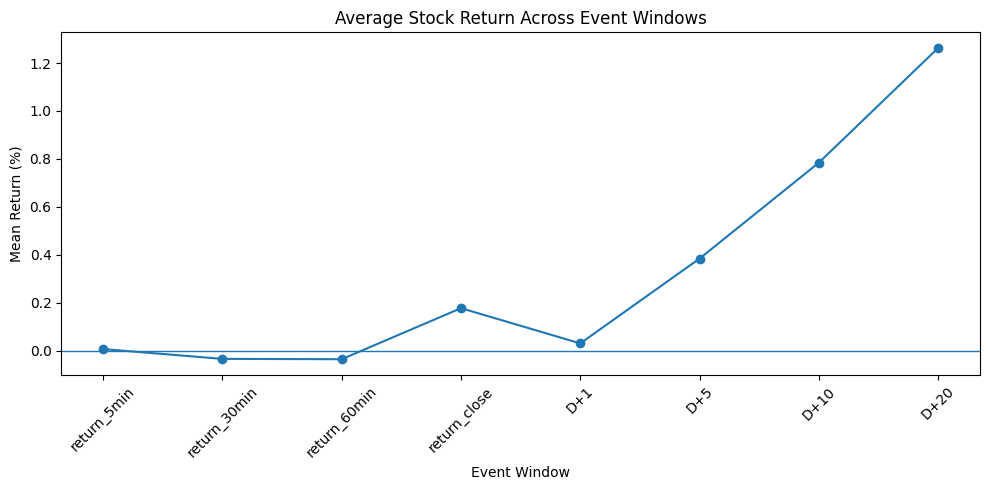

In [89]:
import matplotlib.pyplot as plt

chart_data = overall.copy()

plt.figure(figsize=(10, 5))

plt.plot(
    chart_data["Metric"],
    chart_data["Mean"],
    marker="o"
)

plt.axhline(0, linewidth=1)

plt.title("Average Stock Return Across Event Windows")
plt.xlabel("Event Window")
plt.ylabel("Mean Return (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Company Wise D+20 Chart

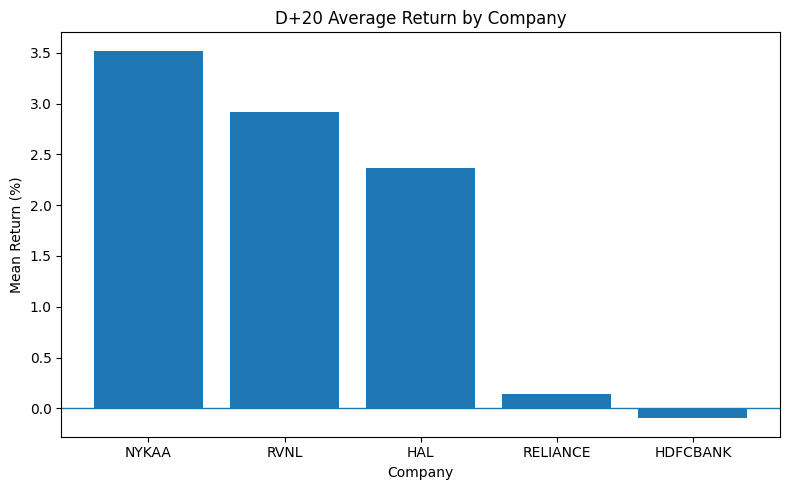

In [90]:
company_d20 = (
    company_analysis[
        company_analysis["Metric"] == "D+20"
    ]
    .sort_values("Mean", ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    company_d20["Company"],
    company_d20["Mean"]
)

plt.axhline(0, linewidth=1)

plt.title("D+20 Average Return by Company")
plt.xlabel("Company")
plt.ylabel("Mean Return (%)")
plt.tight_layout()
plt.show()

Subject wise D+20 chart

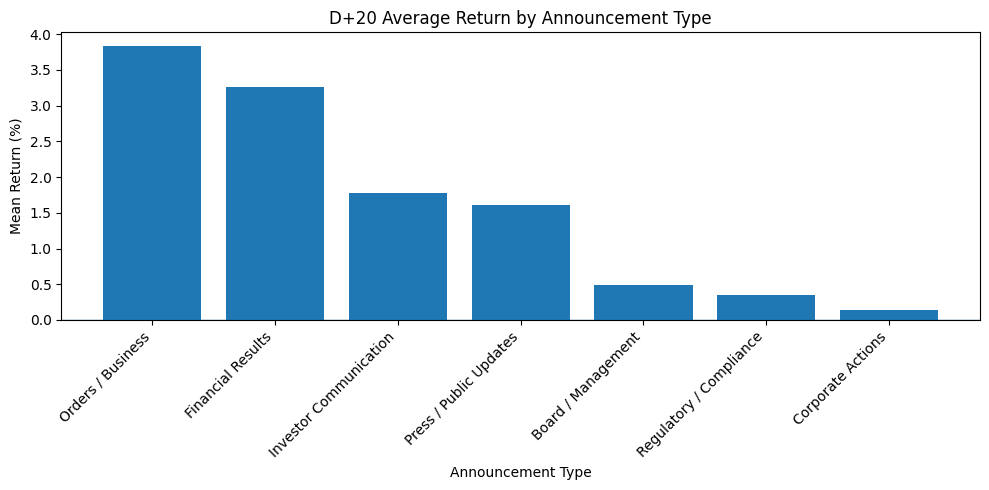

In [91]:
subject_d20 = (
    subject_analysis[
        subject_analysis["Metric"] == "D+20"
    ]
    .sort_values("Mean", ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    subject_d20["Subject_Group"],
    subject_d20["Mean"]
)

plt.axhline(0, linewidth=1)

plt.title("D+20 Average Return by Announcement Type")
plt.xlabel("Announcement Type")
plt.ylabel("Mean Return (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Financial Results Pead

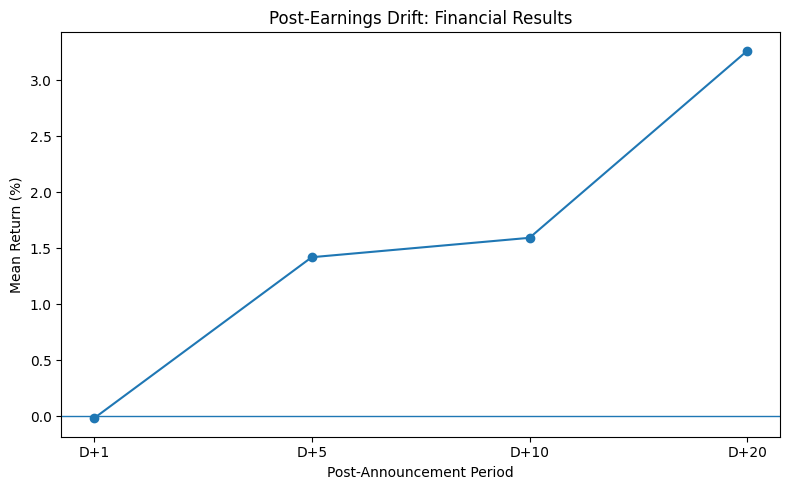

In [92]:
plt.figure(figsize=(8, 5))

plt.plot(
    pead.index,
    pead["mean"],
    marker="o"
)

plt.axhline(0, linewidth=1)

plt.title("Post-Earnings Drift: Financial Results")
plt.xlabel("Post-Announcement Period")
plt.ylabel("Mean Return (%)")
plt.tight_layout()
plt.show()

In [93]:
final_data = df[
    [
        "NEWSID",
        "company",
        "event_time",
        "subject_group",
        "SUBCATNAME",
        "NEWSSUB",
        "CRITICALNEWS",
        "return_5min",
        "return_30min",
        "return_60min",
        "return_close",
        "D+1",
        "D+5",
        "D+10",
        "D+20",
        "volume_impact"
    ]
].copy()

print("Rows:", len(final_data))
print("Columns:", len(final_data.columns))

display(final_data.head())





Rows: 2528
Columns: 16


,NEWSID,company,event_time,subject_group,SUBCATNAME,NEWSSUB,CRITICALNEWS,return_5min,return_30min,return_60min,return_close,D+1,D+5,D+10,D+20,volume_impact
0,d9de7773-d48b-4140-904a-6f736773dc4c,HAL,2023-08-23 17:38:08.580,Corporate Actions,Dividend Updates,Announcement under Regulation 30 (LODR)-Divide...,0,0.284230,-0.127414,-0.735078,-1.821512,-1.688934,-1.386438,1.754474,-2.500630,223.354583
1,5d789c9b-6590-4157-a9c4-2a661aeae2bd,HAL,2023-08-28 17:56:31.123,Press / Public Updates,General,Disclosure Under Regulation 30 Of The SEBI LOD...,0,-0.316052,-0.621910,-0.744252,-0.163683,-0.015370,1.357721,1.188646,-1.716364,-23.077396
2,a68a35aa-c8cb-40f8-b6f7-a065af684a3b,HAL,2023-08-31 17:56:43.077,Corporate Actions,AGM,Shareholder Meeting / Postal Ballot-Outcome of...,1,0.525725,0.653328,1.163740,0.869121,0.631019,4.054739,0.101368,-0.717182,-72.051418
3,31cec2fa-69f9-4098-961d-c9845b8917bd,HAL,2023-09-01 16:15:05.740,Corporate Actions,AGM,Shareholder Meeting / Postal Ballot-Scrutinize...,1,0.146309,-0.181626,-0.131174,0.631019,-0.360120,2.974137,0.397895,-3.548314,-19.512488
4,1dc927a7-73bf-490f-be65-3a36e7119b6a,HAL,2023-09-01 17:01:27.883,Press / Public Updates,General,Disclosures Of Material Events Arising Out Of ...,0,0.146309,-0.181626,-0.131174,0.631019,-0.360120,2.974137,0.397895,-3.548314,-19.512488


In [94]:
print(final_data[
    [
        "return_5min",
        "return_30min",
        "return_60min",
        "return_close",
        "D+1",
        "D+5",
        "D+10",
        "D+20",
        "volume_impact"
    ]
].describe().round(4))

       return_5min  return_30min  return_60min  return_close        D+1  \
count    2528.0000     2528.0000     2528.0000     2528.0000  2528.0000   
mean        0.0068       -0.0341       -0.0355        0.1774     0.0305   
std         0.5816        1.0664        1.2833        2.3377     1.9449   
min        -4.3120       -6.5873       -7.9147      -13.2164   -11.1969   
25%        -0.1941       -0.3872       -0.4930       -0.8490    -0.9131   
50%         0.0076       -0.0224       -0.0299        0.0382    -0.0386   
75%         0.1885        0.3085        0.3835        1.0154     0.8112   
max         5.9196        7.1985        8.8685       17.4442    15.0767   

             D+5       D+10       D+20  volume_impact  
count  2517.0000  2506.0000  2459.0000      2528.0000  
mean      0.3844     0.7847     1.2631        81.5418  
std       4.8498     6.8241     9.2145       357.1887  
min     -18.4975   -20.8473   -30.4498       -98.9443  
25%      -2.1109    -2.9184    -3.9036      

In [95]:
final_data.to_csv(
    'event_analysis_finall.csv',
    index=False
)
print('Saved:', final_data.shape)

Saved: (2528, 16)


In [96]:
from google.colab import files
files.download("event_analysis_finall.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [97]:
from google.colab import files
uploaded = files.upload()

Saving event_analysis_finall.csv to event_analysis_finall (1).csv


In [98]:
import pandas as pd

df1 = pd.read_csv('event_analysis_finall.csv')

In [99]:
print(len(df1))
print(len(df1.columns))

2528
16


In [100]:
print(df1.columns)

Index(['NEWSID', 'company', 'event_time', 'subject_group', 'SUBCATNAME',
       'NEWSSUB', 'CRITICALNEWS', 'return_5min', 'return_30min',
       'return_60min', 'return_close', 'D+1', 'D+5', 'D+10', 'D+20',
       'volume_impact'],
      dtype='object')


In [101]:

df1["event_time"] = pd.to_datetime(df1["event_time"], errors="coerce")


for col in ["subject_group", "SUBCATNAME", "NEWSSUB", "CRITICALNEWS"]:
    df1[col] = df1[col].fillna("").astype(str).str.strip()


df1 = df1.sort_values(["company", "event_time"]).reset_index(drop=True)

print(df1[[
    "NEWSID",
    "company",
    "event_time",
    "subject_group",
    "SUBCATNAME",
    "NEWSSUB"
]].head(10))

                                 NEWSID company              event_time  \
0  d9de7773-d48b-4140-904a-6f736773dc4c     HAL 2023-08-23 17:38:08.580   
1  5d789c9b-6590-4157-a9c4-2a661aeae2bd     HAL 2023-08-28 17:56:31.123   
2  a68a35aa-c8cb-40f8-b6f7-a065af684a3b     HAL 2023-08-31 17:56:43.077   
3  31cec2fa-69f9-4098-961d-c9845b8917bd     HAL 2023-09-01 16:15:05.740   
4  1dc927a7-73bf-490f-be65-3a36e7119b6a     HAL 2023-09-01 17:01:27.883   
5  6e4f0ba2-3234-4376-99c8-779b8c494450     HAL 2023-09-01 17:02:53.890   
6  e71b6c61-387e-45fd-a140-64bfee494ec3     HAL 2023-09-01 17:06:56.487   
7  02f95dcd-6657-49c6-9f86-a69bdf9ca5e6     HAL 2023-09-01 17:09:24.247   
8  7f854943-2b8a-4d5f-a4a7-4538081cd1d5     HAL 2023-09-12 14:31:50.297   
9  a9b41833-c759-4490-b839-c4f0f0b89aac     HAL 2023-09-15 17:22:38.493   

            subject_group                                         SUBCATNAME  \
0       Corporate Actions                                   Dividend Updates   
1  Press / Pub

In [102]:
df1["event_date"] = df1["event_time"].dt.date


df1["potential_group"] = (
    df1["company"].astype(str) + "_" +
    df1["event_date"].astype(str) + "_" +
    df1["subject_group"].astype(str) + "_" +
    df1["SUBCATNAME"].astype(str)
)

print(df1["potential_group"].value_counts().head(20))

potential_group
RELIANCE_2024-02-08_Investor Communication_Analyst / Investor Meet     4
HDFCBANK_2025-04-19_Press / Public Updates_General                     4
RVNL_2024-03-07_Orders / Business_Award of Order / Receipt of Order    3
RVNL_2024-03-28_Press / Public Updates_General                         3
RVNL_2025-02-28_Press / Public Updates_General                         3
RELIANCE_2026-05-20_Press / Public Updates_General                     3
RELIANCE_2025-06-12_Press / Public Updates_General                     3
RVNL_2024-11-05_Press / Public Updates_General                         3
RVNL_2026-02-26_Orders / Business_Award of Order / Receipt of Order    3
RELIANCE_2023-08-28_Corporate Actions_AGM                              3
HDFCBANK_2024-04-26_Press / Public Updates_General                     3
NYKAA_2024-05-22_Press / Public Updates_General                        3
NYKAA_2026-05-13_Investor Communication_Analyst / Investor Meet        3
NYKAA_2024-02-06_Press / Public Upd

In [103]:
df1["time_gap_min"] = (
    df1.groupby("company")["event_time"]
      .diff()
      .dt.total_seconds()
      .div(60)
)

print(df1["time_gap_min"].describe())

count     2523.000000
mean      3107.704760
std       4518.224276
min          0.765217
25%        135.120808
50%       1388.155667
75%       4338.671758
max      50453.563050
Name: time_gap_min, dtype: float64


In [104]:
close = df1[df1["time_gap_min"] <= 30][
    ["company", "event_time", "subject_group",
     "SUBCATNAME", "NEWSSUB", "CRITICALNEWS"]
]

print(close.head(50).to_string(index=False))

 company              event_time           subject_group                                                  SUBCATNAME                                                                                                                                                                                                          NEWSSUB CRITICALNEWS
     HAL 2023-09-01 17:02:53.890  Press / Public Updates          Amendments to Memorandum & Articles of Association                                                                                                                       Announcement under Regulation 30 (LODR)-Amendments to Memorandum & Articles of Association            0
     HAL 2023-09-01 17:06:56.487  Press / Public Updates                                  Sub-division / Stock Split                                                                                                                                                           Corporate Action-Outcome of Sub division / Stock Sp

In [105]:
df1["text_key"] = (
    df1["SUBCATNAME"].str.lower().str.strip() + " | " +
    df1["NEWSSUB"].str.lower().str.strip()
)

df1["exact_related"] = (
    df1.groupby(["company", "text_key"])["event_time"]
       .diff()
       .dt.total_seconds()
       .div(60)
)

print(
    df1[df1["exact_related"].notna()]
    [["company", "event_time", "subject_group",
      "SUBCATNAME", "NEWSSUB", "exact_related"]]
    .head(30)
    .to_string(index=False)
)

company              event_time           subject_group                                                   SUBCATNAME                                                                      NEWSSUB  exact_related
    HAL 2023-09-26 14:03:11.733      Board / Management                           Appointment of Statutory Auditor/s   Announcement under Regulation 30 (LODR)-Appointment of Statutory Auditor/s    5883.242000
    HAL 2023-10-27 15:31:20.277  Press / Public Updates                                Press Release / Media Release        Announcement under Regulation 30 (LODR)-Press Release / Media Release   32999.742500
    HAL 2023-10-31 09:24:14.387      Board / Management                                         Change in Management                 Announcement under Regulation 30 (LODR)-Change in Management   47150.687733
    HAL 2023-11-09 16:09:03.940  Press / Public Updates                                Press Release / Media Release        Announcement under Regulation 30 (LODR)-

In [106]:
df1["same_type_gap_min"] = (
    df1.groupby(["company", "SUBCATNAME", "NEWSSUB"])["event_time"]
       .diff()
       .dt.total_seconds()
       .div(60)
)

close_related = df1[
    df1["same_type_gap_min"].notna() &
    (df1["same_type_gap_min"] <= 60)
]

print(
    close_related[
        ["company", "event_time", "subject_group",
         "SUBCATNAME", "NEWSSUB", "same_type_gap_min"]
    ].to_string(index=False)
)

 company              event_time           subject_group                                                           SUBCATNAME                                                                                             NEWSSUB  same_type_gap_min
     HAL 2024-02-12 14:28:41.607      Board / Management                                             Outcome of Board Meeting                                                      Board Meeting Outcome for 1St Interim Dividend           5.559450
     HAL 2024-11-26 10:14:09.873  Press / Public Updates                                                              General                                                                                General Announcement           5.654217
     HAL 2025-05-01 17:18:07.760  Press / Public Updates                                        Press Release / Media Release                               Announcement under Regulation 30 (LODR)-Press Release / Media Release          18.142283
     HAL 2025-07-16 

In [107]:
df1["content_key"] = (
    df1["SUBCATNAME"].str.lower().str.strip() + " | " +
    df1["NEWSSUB"].str.lower().str.strip() + " | " +
    df1["CRITICALNEWS"].astype(str)
)

df1["duplicate_gap_min"] = (
    df1.groupby(["company", "content_key"])["event_time"]
       .diff()
       .dt.total_seconds()
       .div(60)
)

duplicates = df1[
    df1["duplicate_gap_min"].notna() &
    (df1["duplicate_gap_min"] <= 15)
]

print(
    duplicates[
        ["company", "event_time", "subject_group",
         "SUBCATNAME", "NEWSSUB", "CRITICALNEWS",
         "duplicate_gap_min"]
    ].to_string(index=False)
)

 company              event_time           subject_group                                                           SUBCATNAME                                                                                             NEWSSUB CRITICALNEWS  duplicate_gap_min
     HAL 2024-02-12 14:28:41.607      Board / Management                                             Outcome of Board Meeting                                                      Board Meeting Outcome for 1St Interim Dividend            0           5.559450
     HAL 2024-11-26 10:14:09.873  Press / Public Updates                                                              General                                                                                General Announcement            0           5.654217
     HAL 2025-07-16 09:08:34.680      Board / Management                                                Change in Directorate                                       Announcement under Regulation 30 (LODR)-Change in Directorate 

In [108]:

df1 = df1.sort_values(["company", "event_time"]).reset_index(drop=True)


df1["same_type_gap_min"] = (
    df1.groupby(["company", "SUBCATNAME", "NEWSSUB"])["event_time"]
       .diff()
       .dt.total_seconds()
       .div(60)
)


new_cluster = (
    df1["same_type_gap_min"].isna() |
    (df1["same_type_gap_min"] > 15)
)

df1["event_cluster"] = new_cluster.cumsum()

print("Total announcements:", len(df1))
print("Independent event clusters:", df1["event_cluster"].nunique())

Total announcements: 2528
Independent event clusters: 2455


In [109]:
cluster_sizes = df1["event_cluster"].value_counts()

print("Clusters with multiple announcements:",
      (cluster_sizes > 1).sum())

print("\nCluster size distribution:")
print(cluster_sizes.value_counts().sort_index())

Clusters with multiple announcements: 69

Cluster size distribution:
count
1    2386
2      66
3       2
4       1
Name: count, dtype: int64


In [110]:

df1 = df1.sort_values(["company", "event_time"]).reset_index(drop=True)

df1["gap_min"] = (
    df1.groupby("company")["event_time"]
       .diff()
       .dt.total_seconds()
       .div(60)
)


prev_group = df1["subject_group"].shift()
prev_subcat = df1["SUBCATNAME"].shift()
prev_newssub = df1["NEWSSUB"].shift()


same_detail = (
    (df1["SUBCATNAME"] == prev_subcat) &
    (df1["NEWSSUB"] == prev_newssub)
)


earnings_related = (
    df1["subject_group"].isin([
        "Financial Results",
        "Board / Management",
        "Investor Communication"
    ]) &
    prev_group.isin([
        "Financial Results",
        "Board / Management",
        "Investor Communication"
    ])
)


new_cluster = (
    df1["gap_min"].isna() |
    (df1["gap_min"] > 30) |
    ~(same_detail | earnings_related)
)

df1["event_cluster_corrected"] = new_cluster.cumsum()

print("Total announcements:", len(df1))
print(
    "Corrected independent events:",
    df1["event_cluster_corrected"].nunique()
)

Total announcements: 2528
Corrected independent events: 2396


In [111]:
cluster_sizes = df1["event_cluster_corrected"].value_counts()

print("Clusters with 1 announcement:", (cluster_sizes == 1).sum())
print("Clusters with 2 announcements:", (cluster_sizes == 2).sum())
print("Clusters with 3 announcements:", (cluster_sizes == 3).sum())
print("Clusters with 4+ announcements:", (cluster_sizes >= 4).sum())

print("\nTotal clusters:", len(cluster_sizes))
print("Total announcements:", cluster_sizes.sum())

Clusters with 1 announcement: 2273
Clusters with 2 announcements: 116
Clusters with 3 announcements: 5
Clusters with 4+ announcements: 2

Total clusters: 2396
Total announcements: 2528


In [112]:
table1 = (
    df1.groupby("subject_group")["event_cluster_corrected"]
       .nunique()
       .reset_index(name="Independent Events")
       .sort_values("Independent Events", ascending=False)
)

print(table1.to_string(index=False))

          subject_group  Independent Events
 Press / Public Updates                 943
Regulatory / Compliance                 483
 Investor Communication                 315
     Board / Management                 258
      Corporate Actions                 252
      Orders / Business                 135
      Financial Results                  52


In [113]:

cluster_subject = (
    df1.sort_values("event_time")
       .groupby("event_cluster_corrected")["subject_group"]
       .first()
)

df1["cluster_subject_group"] = df1["event_cluster_corrected"].map(cluster_subject)

table1 = (
    df1.groupby("cluster_subject_group")["event_cluster_corrected"]
       .nunique()
       .reset_index(name="Independent Events")
       .sort_values("Independent Events", ascending=False)
)

print(table1.to_string(index=False))
print("\nTotal:", table1["Independent Events"].sum())

  cluster_subject_group  Independent Events
 Press / Public Updates                 943
Regulatory / Compliance                 483
 Investor Communication                 298
      Corporate Actions                 252
     Board / Management                 246
      Orders / Business                 135
      Financial Results                  39

Total: 2396


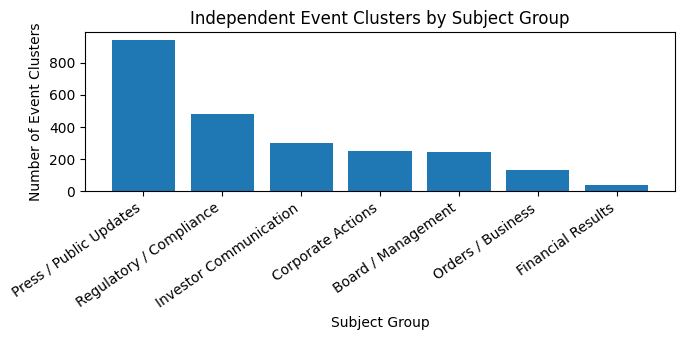

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3.5))

plt.bar(
    table1["cluster_subject_group"],
    table1["Independent Events"]
)

plt.title("Independent Event Clusters by Subject Group")
plt.xlabel("Subject Group")
plt.ylabel("Number of Event Clusters")

plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig(
    "Figure_2_Event_Clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [115]:
from google.colab import files
files.download('Figure_2_Event_Clusters.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [116]:
print(df1[
    [
        "return_5min",
        "return_30min",
        "return_60min",
        "return_close",
        "D+1",
        "D+5",
        "D+10",
        "D+20"
    ]
].describe().T)

               count      mean       std        min       25%       50%  \
return_5min   2528.0  0.006794  0.581560  -4.311975 -0.194053  0.007586   
return_30min  2528.0 -0.034071  1.066362  -6.587324 -0.387156 -0.022361   
return_60min  2528.0 -0.035498  1.283311  -7.914706 -0.492958 -0.029882   
return_close  2528.0  0.177368  2.337704 -13.216403 -0.848999  0.038247   
D+1           2528.0  0.030549  1.944874 -11.196911 -0.913088 -0.038641   
D+5           2517.0  0.384450  4.849764 -18.497519 -2.110927  0.271191   
D+10          2506.0  0.784655  6.824061 -20.847280 -2.918408  0.123865   
D+20          2459.0  1.263086  9.214508 -30.449791 -3.903611 -0.126665   

                   75%        max  
return_5min   0.188530   5.919616  
return_30min  0.308510   7.198533  
return_60min  0.383549   8.868502  
return_close  1.015406  17.444219  
D+1           0.811245  15.076704  
D+5           2.344468  47.687515  
D+10          3.463652  55.651470  
D+20          5.269050  65.232975  


In [117]:
print(df1['volume_impact'].describe())

count     2528.000000
mean        81.541840
std        357.188738
min        -98.944344
25%        -41.216491
50%          0.415424
75%         75.405245
max      11536.729087
Name: volume_impact, dtype: float64


In [118]:
df1["volatility"] = df1[
    ["return_5min", "return_30min", "return_60min"]
].std(axis=1)

print(df1["volatility"].describe())

count    2528.000000
mean        0.410169
std         0.467474
min         0.000000
25%         0.147806
50%         0.270832
75%         0.479583
max         3.485188
Name: volatility, dtype: float64


In [119]:
from scipy.stats import ttest_1samp

cols = [
    "return_5min",
    "return_30min",
    "return_60min",
    "return_close",
    "volume_impact"
]

for col in cols:
    x = df1[col].dropna()
    t_stat, p_value = ttest_1samp(x, 0)

    print(f"{col}")
    print(f"Mean = {x.mean():.6f}")
    print(f"t-statistic = {t_stat:.4f}")
    print(f"p-value = {p_value:.6f}")
    print("-" * 40)

return_5min
Mean = 0.006794
t-statistic = 0.5874
p-value = 0.557019
----------------------------------------
return_30min
Mean = -0.034071
t-statistic = -1.6064
p-value = 0.108302
----------------------------------------
return_60min
Mean = -0.035498
t-statistic = -1.3908
p-value = 0.164411
----------------------------------------
return_close
Mean = 0.177368
t-statistic = 3.8148
p-value = 0.000140
----------------------------------------
volume_impact
Mean = 81.541840
t-statistic = 11.4781
p-value = 0.000000
----------------------------------------


In [120]:
df1["strong_impact"] = (
    df1["return_close"].abs() >= 2
)

print("Strong impact events:", df1["strong_impact"].sum())
print("Total events:", len(df1))
print(
    "Strong impact percentage:",
    df1["strong_impact"].mean() * 100
)

Strong impact events: 597
Total events: 2528
Strong impact percentage: 23.615506329113924


In [121]:
subject_results = (
    df1.groupby("subject_group")
       .agg(
           Events=("event_cluster_corrected", "nunique"),
           Mean_Close_Return=("return_close", "mean"),
           Mean_Volume_Impact=("volume_impact", "mean"),
           Strong_Impact_Events=("strong_impact", "sum")
       )
       .reset_index()
       .sort_values("Mean_Close_Return", ascending=False)
)

print(subject_results.to_string(index=False))

          subject_group  Events  Mean_Close_Return  Mean_Volume_Impact  Strong_Impact_Events
      Orders / Business     135           0.903366          239.641928                    43
 Press / Public Updates     943           0.268569           78.224777                   254
 Investor Communication     315           0.129700          120.971889                    89
Regulatory / Compliance     483           0.064098            7.233402                    65
      Corporate Actions     252           0.031882            5.525573                    41
     Board / Management     258           0.005607          101.136610                    75
      Financial Results      52          -0.416472          476.514741                    30


In [122]:
print(len(df1))

2528


In [123]:
print(df1.columns)

Index(['NEWSID', 'company', 'event_time', 'subject_group', 'SUBCATNAME',
       'NEWSSUB', 'CRITICALNEWS', 'return_5min', 'return_30min',
       'return_60min', 'return_close', 'D+1', 'D+5', 'D+10', 'D+20',
       'volume_impact', 'event_date', 'potential_group', 'time_gap_min',
       'text_key', 'exact_related', 'same_type_gap_min', 'content_key',
       'duplicate_gap_min', 'event_cluster', 'gap_min',
       'event_cluster_corrected', 'cluster_subject_group', 'volatility',
       'strong_impact'],
      dtype='object')


In [124]:
print(len(df1.columns))

30


In [125]:
print(df1.head())

                                 NEWSID company              event_time  \
0  d9de7773-d48b-4140-904a-6f736773dc4c     HAL 2023-08-23 17:38:08.580   
1  5d789c9b-6590-4157-a9c4-2a661aeae2bd     HAL 2023-08-28 17:56:31.123   
2  a68a35aa-c8cb-40f8-b6f7-a065af684a3b     HAL 2023-08-31 17:56:43.077   
3  31cec2fa-69f9-4098-961d-c9845b8917bd     HAL 2023-09-01 16:15:05.740   
4  1dc927a7-73bf-490f-be65-3a36e7119b6a     HAL 2023-09-01 17:01:27.883   

            subject_group        SUBCATNAME  \
0       Corporate Actions  Dividend Updates   
1  Press / Public Updates           General   
2       Corporate Actions               AGM   
3       Corporate Actions               AGM   
4  Press / Public Updates           General   

                                             NEWSSUB CRITICALNEWS  \
0  Announcement under Regulation 30 (LODR)-Divide...            0   
1  Disclosure Under Regulation 30 Of The SEBI LOD...            0   
2  Shareholder Meeting / Postal Ballot-Outcome of...       

In [126]:
print(df1['event_cluster_corrected'].nunique())
print(df1['volatility'].describe())
print(df1['strong_impact'].value_counts())

2396
count    2528.000000
mean        0.410169
std         0.467474
min         0.000000
25%         0.147806
50%         0.270832
75%         0.479583
max         3.485188
Name: volatility, dtype: float64
strong_impact
False    1931
True      597
Name: count, dtype: int64


In [127]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [128]:
import pandas as pd

pead_summary = pd.DataFrame({
    "Horizon": ["D0", "D+1", "D+3", "D+5", "D+10", "D+20"],
    "N": [52, 52, 52, 52, 50, 49],
    "Mean (%)": [-0.276400, -0.255786, 0.357173, 1.000381, 1.003106, 2.674601],
    "Median (%)": [-0.614663, -0.416571, -0.141978, 0.689053, -0.553870, 0.432277],
    "Continuation (%)": [None, 53.846154, 59.615385, 61.538462, 74.000000, 63.265306],
    "T-stat": [-0.617310, -0.607273, 0.522891, 1.327671, 0.974702, 1.953971],
    "P-value": [0.539777, 0.546364, 0.603315, 0.190199, 0.334496, 0.056545]
})

pead_summary.to_csv(
    "/content/drive/MyDrive/pead_summary.csv",
    index=False
)

print(pead_summary)
print("\n pead_summary.csv saved")

  Horizon   N  Mean (%)  Median (%)  Continuation (%)    T-stat   P-value
0      D0  52 -0.276400   -0.614663               NaN -0.617310  0.539777
1     D+1  52 -0.255786   -0.416571         53.846154 -0.607273  0.546364
2     D+3  52  0.357173   -0.141978         59.615385  0.522891  0.603315
3     D+5  52  1.000381    0.689053         61.538462  1.327671  0.190199
4    D+10  50  1.003106   -0.553870         74.000000  0.974702  0.334496
5    D+20  49  2.674601    0.432277         63.265306  1.953971  0.056545

 pead_summary.csv saved


In [129]:

event_level_results = df1.copy()

event_level_results["effective_event_time"] = df1["event_time"]
event_level_results["exclusion_reason"] = ""

event_level_results.to_csv(
    "/content/drive/MyDrive/event_level_results.csv",
    index=False
)



subject_summary = (
    df1.groupby("subject_group")
    .agg(
        Events=("event_cluster_corrected", "nunique"),
        Mean_Return=("return_close", "mean"),
        Median_Return=("return_close", "median"),
        Mean_Volume_Impact=("volume_impact", "mean"),
        Median_Volume_Impact=("volume_impact", "median"),
        Mean_Volatility=("volatility", "mean"),
        Strong_Impact_Events=("strong_impact", "sum")
    )
    .reset_index()
)

subject_summary.to_csv(
    "/content/drive/MyDrive/subject_summary.csv",
    index=False
)



pead_summary.to_csv(
    "/content/drive/MyDrive/pead_summary.csv",
    index=False
)


print(" ALL 3 CSV FILES CREATED")
print("Event-level rows:", len(event_level_results))
print("Independent events:", df1["event_cluster_corrected"].nunique())
print("Subject groups:", len(subject_summary))
print("PEAD rows:", len(pead_summary))

 ALL 3 CSV FILES CREATED
Event-level rows: 2528
Independent events: 2396
Subject groups: 7
PEAD rows: 6


In [130]:
import os

for f in [
    "event_level_results.csv",
    "subject_summary.csv",
    "pead_summary.csv"
]:
    path = "/content/drive/MyDrive/" + f
    print(f, "→", "EXISTS" if os.path.exists(path) else "MISSING")

event_level_results.csv → EXISTS
subject_summary.csv → EXISTS
pead_summary.csv → EXISTS


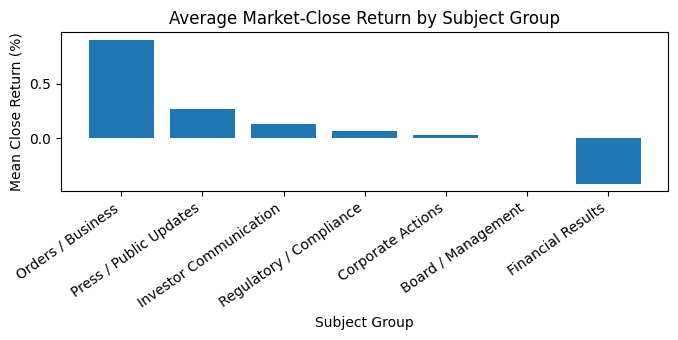

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3.5))

plt.bar(
    subject_results["subject_group"],
    subject_results["Mean_Close_Return"]
)

plt.title("Average Market-Close Return by Subject Group")
plt.xlabel("Subject Group")
plt.ylabel("Mean Close Return (%)")

plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig(
    "Figure_3_Subject_Return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [132]:
from google.colab import files
files.download('Figure_3_Subject_Return.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

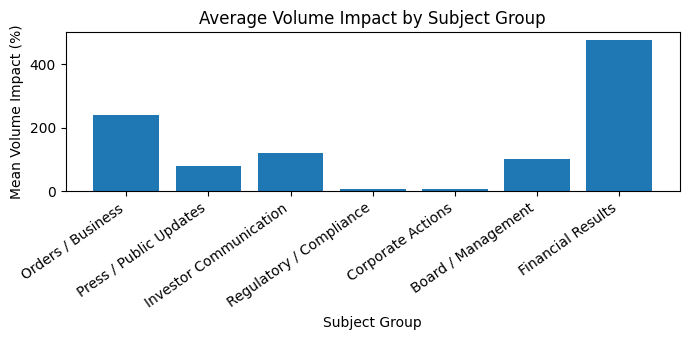

In [133]:
plt.figure(figsize=(7, 3.5))

plt.bar(
    subject_results["subject_group"],
    subject_results["Mean_Volume_Impact"]
)

plt.title("Average Volume Impact by Subject Group")
plt.xlabel("Subject Group")
plt.ylabel("Mean Volume Impact (%)")

plt.xticks(rotation=35, ha="right")
plt.tight_layout()

plt.savefig(
    "Figure_4_Subject_Volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [134]:
from google.colab import files
files.download('Figure_4_Subject_Volume.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [135]:
stock_results = (
    df1.groupby("company")
       .agg(
           Events=("event_cluster_corrected", "nunique"),
           Mean_Close_Return=("return_close", "mean"),
           Mean_Volume_Impact=("volume_impact", "mean"),
           Strong_Impact_Events=("strong_impact", "sum")
       )
       .reset_index()
       .sort_values("Mean_Close_Return", ascending=False)
)

print(stock_results.to_string(index=False))

 company  Events  Mean_Close_Return  Mean_Volume_Impact  Strong_Impact_Events
    RVNL     443           0.562856          174.399534                   191
     HAL     267           0.402941           90.311866                    90
   NYKAA     321           0.196871          216.154287                   125
RELIANCE     767           0.014262            6.573184                   108
HDFCBANK     598          -0.004573           35.481393                    83


In [136]:
earnings = df1[
    df1["subject_group"] == "Financial Results"
].copy()

print("Financial-result announcements:", len(earnings))
print(
    "Independent earnings events:",
    earnings["event_cluster_corrected"].nunique()
)

Financial-result announcements: 53
Independent earnings events: 52


In [137]:
print(earnings.columns)

Index(['NEWSID', 'company', 'event_time', 'subject_group', 'SUBCATNAME',
       'NEWSSUB', 'CRITICALNEWS', 'return_5min', 'return_30min',
       'return_60min', 'return_close', 'D+1', 'D+5', 'D+10', 'D+20',
       'volume_impact', 'event_date', 'potential_group', 'time_gap_min',
       'text_key', 'exact_related', 'same_type_gap_min', 'content_key',
       'duplicate_gap_min', 'event_cluster', 'gap_min',
       'event_cluster_corrected', 'cluster_subject_group', 'volatility',
       'strong_impact'],
      dtype='object')


In [138]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [139]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Copy of Sales_Data_Advanced.xlsx', 'Sales_Data_Advanced.xlsx', 'Colab Notebooks', '83bc13f5.csv', 'FaceShape_project', 'Quant Analyst Intern', 'market_data.csv', 'Figure5_PEAD.png', 'pead_summary.csv', 'subject_summary.csv', 'event_level_results.csv']


In [140]:
market = pd.read_csv('/content/drive/MyDrive/market_data.csv')

In [141]:

market["date"] = pd.to_datetime(market["date"])
market = market.sort_values(["company", "date"])

earnings = (
    df1[df1["subject_group"] == "Financial Results"]
    .sort_values("event_time")
    .drop_duplicates("event_cluster_corrected")
    .copy()
)

earnings["event_time"] = pd.to_datetime(earnings["event_time"])

rows = []

for _, e in earnings.iterrows():

    m = market[market["company"] == e["company"]].copy()
    m["session"] = m["date"].dt.normalize()

    sessions = sorted(m["session"].unique())

    after = m[m["date"] >= e["event_time"]]
    before = m[m["date"] < e["event_time"]]

    if after.empty or before.empty:
        continue

    d0 = after.iloc[0]["session"]
    i = sessions.index(d0)


    pre_price = before.iloc[-1]["close"]
    d0_close = m[m["session"] == d0].iloc[-1]["close"]

    row = {
        "company": e["company"],
        "event_time": e["event_time"],
        "D0": (d0_close / pre_price - 1) * 100
    }

    for h in [1, 3, 5, 10, 20]:
        if i + h < len(sessions):
            future_close = m[
                m["session"] == sessions[i + h]
            ].iloc[-1]["close"]

            row[f"D+{h}"] = (future_close / d0_close - 1) * 100
        else:
            row[f"D+{h}"] = np.nan

    rows.append(row)

pead = pd.DataFrame(rows)

print("Independent earnings events:", len(earnings))
print("Usable PEAD events:", len(pead))
print(pead.to_string(index=False))

Independent earnings events: 52
Usable PEAD events: 52
 company              event_time        D0        D+1       D+3       D+5       D+10       D+20
RELIANCE 2023-10-27 19:23:39.370  1.987633  -0.866176  0.433088  1.277609   0.948463   3.733218
   NYKAA 2023-11-06 15:40:54.333  1.186843  -0.067024  0.536193  1.407507  15.382038  16.253351
    RVNL 2023-11-09 16:41:01.890 -2.647150   1.471529  2.015355  6.429942   6.909789  13.883557
     HAL 2023-11-10 13:50:21.300 -0.459937   0.948444  1.653696  3.232004   9.387160  35.943580
RELIANCE 2024-01-19 18:14:04.777 -0.672416  -2.251656 -0.257542  3.686534   5.077263   8.219279
   NYKAA 2024-02-06 15:30:12.647 -2.928349  -2.471117 -6.675225 -1.155327  -3.080873   2.503209
    RVNL 2024-02-08 16:32:24.460 -7.894737 -11.196911 -3.745174 -2.837838   2.104247  -8.262548
     HAL 2024-02-12 14:03:01.463 -0.833973   2.584539  6.238784  6.548436   7.463317  18.631901
HDFCBANK 2024-04-20 14:33:08.687 -1.290575  -0.449023 -0.026413  0.937665  -0.581

In [142]:
from scipy.stats import ttest_1samp

summary = []

for h in ["D0", "D+1", "D+3", "D+5", "D+10", "D+20"]:

    x = pead[h].dropna()

    t, p = ttest_1samp(x, 0)

    if h == "D0":
        continuation = np.nan
    else:
        direction = np.sign(pead.loc[x.index, "D0"])
        continuation = (np.sign(x) == direction).mean() * 100

    summary.append({
        "Horizon": h,
        "N": len(x),
        "Mean (%)": x.mean(),
        "Median (%)": x.median(),
        "Continuation (%)": continuation,
        "T-stat": t,
        "P-value": p
    })

pead_summary = pd.DataFrame(summary)

print(pead_summary.to_string(index=False))

pead_summary.to_csv(
    "/content/drive/MyDrive/pead_summary.csv",
    index=False
)

Horizon  N  Mean (%)  Median (%)  Continuation (%)    T-stat  P-value
     D0 52 -0.276400   -0.614663               NaN -0.617310 0.539777
    D+1 52 -0.255786   -0.416571         53.846154 -0.607273 0.546364
    D+3 52  0.357173   -0.141978         59.615385  0.522891 0.603315
    D+5 52  1.000381    0.689053         61.538462  1.327671 0.190199
   D+10 50  1.003106   -0.553870         74.000000  0.974702 0.334496
   D+20 49  2.674601    0.432277         63.265306  1.953971 0.056545


In [143]:
stock_pead = []

for company, g in pead.groupby("company"):

    for h in ["D0", "D+1", "D+3", "D+5", "D+10", "D+20"]:

        x = g[h].dropna()

        if len(x) == 0:
            continue

        if h == "D0":
            continuation = np.nan
        else:
            direction = np.sign(g.loc[x.index, "D0"])
            continuation = (
                (np.sign(x) == direction).mean() * 100
            )

        stock_pead.append({
            "company": company,
            "horizon": h,
            "N": len(x),
            "Mean (%)": x.mean(),
            "Median (%)": x.median(),
            "Continuation (%)": continuation
        })

stock_pead = pd.DataFrame(stock_pead)

print(stock_pead.to_string(index=False))

 company horizon  N  Mean (%)  Median (%)  Continuation (%)
     HAL      D0 11  0.858507   -0.281507               NaN
     HAL     D+1 11  0.279996    0.948444         27.272727
     HAL     D+3 11  1.001635    1.706558         54.545455
     HAL     D+5 11  1.622972    2.350542         63.636364
     HAL    D+10 10  1.552339    2.042489         70.000000
     HAL    D+20 10  6.341021    4.524954         80.000000
HDFCBANK      D0  6 -0.396868    0.208973               NaN
HDFCBANK     D+1  6 -0.101471   -0.433842         50.000000
HDFCBANK     D+3  6 -1.705532   -1.502230         50.000000
HDFCBANK     D+5  6 -1.132434   -0.436041         50.000000
HDFCBANK    D+10  6 -0.884360   -1.082262         83.333333
HDFCBANK    D+20  6 -2.012575   -2.171762         66.666667
   NYKAA      D0 12  0.172089   -0.642121               NaN
   NYKAA     D+1 12 -0.402079   -0.112516         58.333333
   NYKAA     D+3 12 -0.979021   -0.608104         66.666667
   NYKAA     D+5 12  0.694381    0.12609

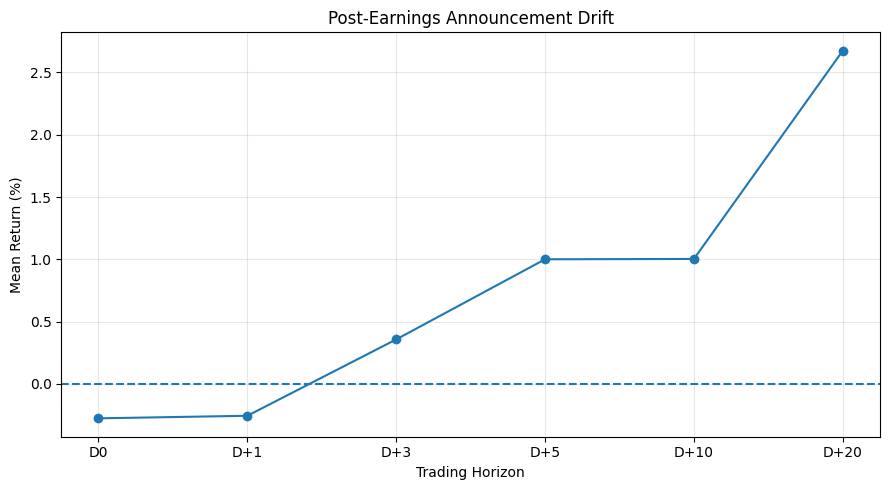

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    pead_summary["Horizon"],
    pead_summary["Mean (%)"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Post-Earnings Announcement Drift")
plt.xlabel("Trading Horizon")
plt.ylabel("Mean Return (%)")
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/Figure5_PEAD.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [145]:
from google.colab import files
files.download("/content/drive/MyDrive/Figure5_PEAD.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [146]:
print(df1.columns.tolist())

['NEWSID', 'company', 'event_time', 'subject_group', 'SUBCATNAME', 'NEWSSUB', 'CRITICALNEWS', 'return_5min', 'return_30min', 'return_60min', 'return_close', 'D+1', 'D+5', 'D+10', 'D+20', 'volume_impact', 'event_date', 'potential_group', 'time_gap_min', 'text_key', 'exact_related', 'same_type_gap_min', 'content_key', 'duplicate_gap_min', 'event_cluster', 'gap_min', 'event_cluster_corrected', 'cluster_subject_group', 'volatility', 'strong_impact']


In [147]:
subject_summary = (
    earnings.groupby("subject_group")
    .agg(
        Events=("event_cluster_corrected", "nunique"),
        Mean_Return=("return_close", "mean"),
        Median_Return=("return_close", "median"),
        Mean_Volume_Impact=("volume_impact", "mean"),
        Median_Volume_Impact=("volume_impact", "median"),
        Mean_Volatility=("volatility", "mean"),
        Strong_Impact_Events=("strong_impact", "sum")
    )
    .reset_index()
)

subject_summary.to_csv(
    "/content/drive/MyDrive/subject_summary.csv",
    index=False
)

print(subject_summary.to_string(index=False))

    subject_group  Events  Mean_Return  Median_Return  Mean_Volume_Impact  Median_Volume_Impact  Mean_Volatility  Strong_Impact_Events
Financial Results      52    -0.486773      -0.559633          484.076869            305.672863         0.758998                    29


In [148]:
print(df1['subject_group'].value_counts())

subject_group
Press / Public Updates     949
Regulatory / Compliance    527
Investor Communication     331
Board / Management         268
Corporate Actions          257
Orders / Business          143
Financial Results           53
Name: count, dtype: int64


In [149]:
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        cols = set(obj.columns)
        found = {
            "event_cluster_corrected",
            "volatility",
            "strong_impact"
        } & cols

        if found:
            print(
                name,
                "→",
                found,
                "→ rows:",
                len(obj)
            )

df1 → {'volatility', 'strong_impact', 'event_cluster_corrected'} → rows: 2528
event_level_results → {'volatility', 'strong_impact', 'event_cluster_corrected'} → rows: 2528
earnings → {'volatility', 'strong_impact', 'event_cluster_corrected'} → rows: 52
